# 2-Chip Placement Optimization

Finds optimal chip positions on a heat sink to minimize weighted thermal resistance.

**Prerequisites:** py2femm server running on `localhost:8082`

In [1]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path
repo_root = Path.cwd().resolve()
while repo_root.name and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

example_dir = str(repo_root / "examples" / "heatflow" / "heatsink")
if example_dir not in sys.path:
    sys.path.insert(0, example_dir)

import heatsink_optimize as opt
from py2femm.client import FemmClient

import matplotlib
%matplotlib inline

assert opt.server_is_healthy(), "py2femm server not running on localhost:8082"
print("Server OK")

cfg = opt.OptimConfig(grid_n=5, max_iter=15, timeout=60)
client = FemmClient(mode="remote", url="http://localhost:8082")
print(f"Base: {cfg.heatsink.base_w}x{cfg.heatsink.base_h} mm")
print(f"ChipA: {cfg.chip_a.power}W, ChipB: {cfg.chip_b.power}W")

Server OK
Base: 210.0x297.0 mm
ChipA: 5.0W, ChipB: 15.0W


In [2]:
grid_results = opt.brute_force(cfg, client)
print(f"\n{len(grid_results)} feasible points evaluated")


=== Brute-Force Grid (5x5 = 25 combinations) ===
R_thA=3.700, R_thB=1.216, obj=2.458
R_thA=3.410, R_thB=1.147, obj=2.278
R_thA=3.235, R_thB=1.157, obj=2.196
R_thA=3.166, R_thB=1.253, obj=2.209
R_thA=3.596, R_thB=1.320, obj=2.458
R_thA=3.383, R_thB=1.156, obj=2.269
R_thA=3.202, R_thB=1.166, obj=2.184
R_thA=3.131, R_thB=1.261, obj=2.196
R_thA=3.273, R_thB=1.283, obj=2.278
R_thA=3.350, R_thB=1.189, obj=2.269
R_thA=3.350, R_thB=1.189, obj=2.269
R_thA=3.273, R_thB=1.283, obj=2.278
R_thA=3.131, R_thB=1.261, obj=2.196
R_thA=3.202, R_thB=1.166, obj=2.184
R_thA=3.383, R_thB=1.156, obj=2.269
R_thA=3.596, R_thB=1.319, obj=2.458
R_thA=3.166, R_thB=1.253, obj=2.209
R_thA=3.235, R_thB=1.157, obj=2.196
R_thA=3.410, R_thB=1.147, obj=2.278
R_thA=3.700, R_thB=1.216, obj=2.458

  Evaluated: 20, Skipped (infeasible): 5
  Best: xA=57.5, xB=152.5, obj=2.184

20 feasible points evaluated


In [3]:
scipy_result = None
if grid_results:
    best_grid = min(grid_results, key=lambda r: r["objective"])
    scipy_result = opt.scipy_optimize(cfg, client, x0=(best_grid["x_a"], best_grid["x_b"]))


=== Scipy Nelder-Mead (max 15 iter) ===
  x0 = (57.5, 152.5)
obj=2.184#1] xA=57.5, xB=152.5... 
obj=2.186#2] xA=60.4, xB=152.5... 
obj=2.179#3] xA=57.5, xB=160.1... 
obj=2.177#4] xA=54.6, xB=160.1... 
obj=2.174#5] xA=51.8, xB=163.9... 
obj=2.173#6] xA=51.8, xB=171.6... 
obj=2.174#7] xA=48.9, xB=181.1... 
obj=2.171#8] xA=46.0, xB=175.4... 
obj=2.174#9] xA=40.2, xB=183.0... 
obj=2.174#10] xA=46.0, xB=183.0... 
obj=2.173#11] xA=50.3, xB=168.7... 
obj=2.171#12] xA=44.6, xB=172.5... 
obj=2.170#13] xA=41.0, xB=173.0... 
obj=2.172#14] xA=36.7, xB=179.7... 
obj=2.171#15] xA=40.1, xB=176.9... 
obj=2.171#16] xA=35.0, xB=174.5... 
obj=2.170#17] xA=35.9, xB=170.6... 
obj=2.170#18] xA=41.9, xB=169.1... 
obj=2.171#19] xA=45.3, xB=166.3... 
obj=2.171#20] xA=46.9, xB=171.4... 
obj=2.170#21] xA=38.7, xB=170.8... 
obj=2.170#22] xA=39.6, xB=166.9... 
obj=2.170#23] xA=40.6, xB=171.5... 
obj=2.170#24] xA=37.4, xB=173.2... 
obj=2.170#25] xA=40.8, xB=170.1... 
obj=2.170#26] xA=38.8, xB=169.5... 
obj=2.170#2

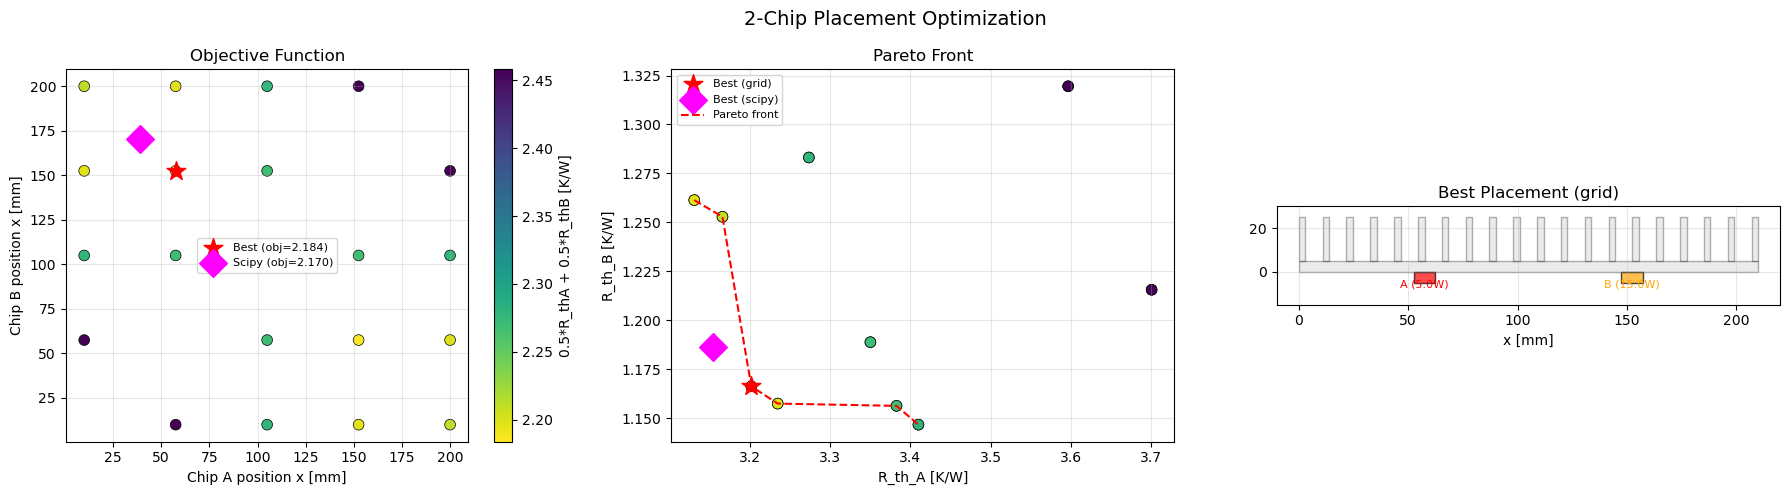

In [4]:
opt.plot_grid_results(cfg, grid_results, scipy_result)